In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

from mpl_toolkits.mplot3d import Axes3D

In [ ]:
import pandas as pd

# Create sample dataset
data = {
    'Area': [1000, 1200, 1500, 1800, 2000, 2200, 2500, 2700, 3000, 3200],
    'Bedrooms': [2, 2, 3, 3, 3, 4, 4, 4, 5, 5],
    'Price': [200000, 230000, 300000, 340000, 380000, 420000, 480000, 520000, 600000, 650000]
}

# Convert dictionary into DataFrame
df = pd.DataFrame(data)

# Display the dataset
df

,Area,Bedrooms,Price
0,1000,2,200000
1,1200,2,230000
2,1500,3,300000
3,1800,3,340000
4,2000,3,380000
5,2200,4,420000
6,2500,4,480000
7,2700,4,520000
8,3000,5,600000
9,3200,5,650000


In [ ]:
data = {
    'Area': [1000, 1200, 1500],
    'Bedrooms': [2, 2, 3],
    'Price': [200000, 230000, 300000]
}

In [ ]:
# Independent variables (Features)
X = df[['Area', 'Bedrooms']]

# Dependent variable (Target)
y = df['Price']

print("Features:")
print(X)

print("\nTarget:")
print(y)

Features:
   Area  Bedrooms
0  1000         2
1  1200         2
2  1500         3
3  1800         3
4  2000         3
5  2200         4
6  2500         4
7  2700         4
8  3000         5
9  3200         5

Target:
0    200000
1    230000
2    300000
3    340000
4    380000
5    420000
6    480000
7    520000
8    600000
9    650000
Name: Price, dtype: int64


In [ ]:
from sklearn.linear_model import LinearRegression

# Create the Linear Regression model
model = LinearRegression()

# Train the model using the dataset
model.fit(X, y)

print("Model trained successfully!")

Model trained successfully!


In [ ]:
print("Coefficient for Area:", model.coef_[0])
print("Coefficient for Bedrooms:", model.coef_[1])
print("Intercept:", model.intercept_)

Coefficient for Area: 178.23984526112176
Coefficient for Bedrooms: 16515.151515151523
Intercept: -21889.10380399722


In [ ]:
# Predict prices for the existing dataset
predicted_price = model.predict(X)

print(predicted_price)

[189381.04448743 225029.01353965 295016.11863314 348488.07221148
 384136.0412637  436299.16183108 489771.11540941 525419.08446164
 595406.18955513 631054.15860735]


In [ ]:
import numpy as np

# Create a range of Area values
area_range = np.linspace(df['Area'].min(), df['Area'].max(), 20)

# Create a range of Bedroom values
bedroom_range = np.linspace(df['Bedrooms'].min(), df['Bedrooms'].max(), 20)

# Create the mesh grid
AreaGrid, BedroomGrid = np.meshgrid(area_range, bedroom_range)

print("Mesh Grid Created Successfully!")

Mesh Grid Created Successfully!


In [ ]:
# Predict prices for every point in the mesh grid
grid_predictions = model.predict(
    np.c_[AreaGrid.ravel(), BedroomGrid.ravel()]
)

# Convert predictions back to grid shape
PriceGrid = grid_predictions.reshape(AreaGrid.shape)

print("Regression Plane Ready!")

Regression Plane Ready!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


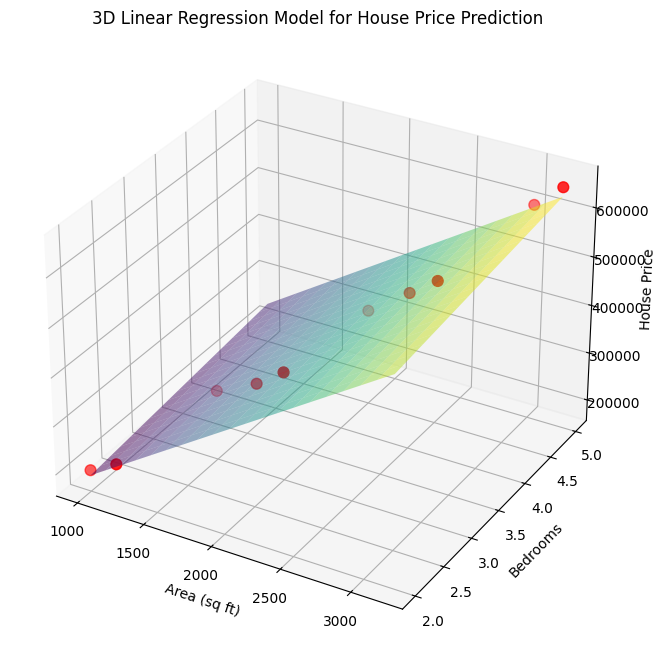

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create figure
fig = plt.figure(figsize=(10, 8))

# Add 3D axis
ax = fig.add_subplot(111, projection='3d')

# Plot actual data points
ax.scatter(
    df['Area'],
    df['Bedrooms'],
    df['Price'],
    color='red',
    s=60,
    label='Actual Data'
)

# Plot regression surface
ax.plot_surface(
    AreaGrid,
    BedroomGrid,
    PriceGrid,
    alpha=0.5,
    cmap='viridis'
)

# Labels
ax.set_xlabel("Area (sq ft)")
ax.set_ylabel("Bedrooms")
ax.set_zlabel("House Price")

# Title
ax.set_title("3D Linear Regression Model for House Price Prediction")

plt.show()